# Predictive Maintenance in Solar Power System using Machine Learning

## Objective

The goal of this project is to predict solar power generation using environmental and sensor data, and detect maintenance requirements by comparing predicted and actual power output.

If the deviation is high, the system flags a maintenance alert.

## Use Cases

- Solar plant monitoring
- Predictive maintenance
- Fault detection
- Efficiency optimization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
generation = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

In [4]:
generation.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [11]:
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [12]:
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'], dayfirst=True)
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [13]:
data = pd.merge(generation, weather, on="DATE_TIME")
print(data.shape)

(68774, 12)


In [15]:
data = pd.merge(
    generation,
    weather,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

In [16]:
print(data.shape)
print(data.head())

(68774, 11)
   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    6183645.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6987759.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7602960.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    7158964.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3     

In [17]:
data = data[data['IRRADIATION'] > 0]

In [18]:
print(data.shape)

(38376, 11)


In [19]:
X = data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y = data['AC_POWER']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
predicted = model.predict(X_test)

===== SAMPLE OUTPUT =====
   Actual Power  Predicted Power          Status
0    915.828571       939.553188  ✅ Working Fine
1      0.000000         0.000000   ⚠️ Low Output
2    420.516667       487.381580  ✅ Working Fine
3    180.862500       177.216019  ✅ Working Fine
4    464.700000       475.887426  ✅ Working Fine
5      0.000000         0.000000   ⚠️ Low Output
6    593.962500       588.195155  ✅ Working Fine
7      0.000000         0.000000   ⚠️ Low Output
8    179.785714       174.609888  ✅ Working Fine
9    586.814286       583.418438  ✅ Working Fine


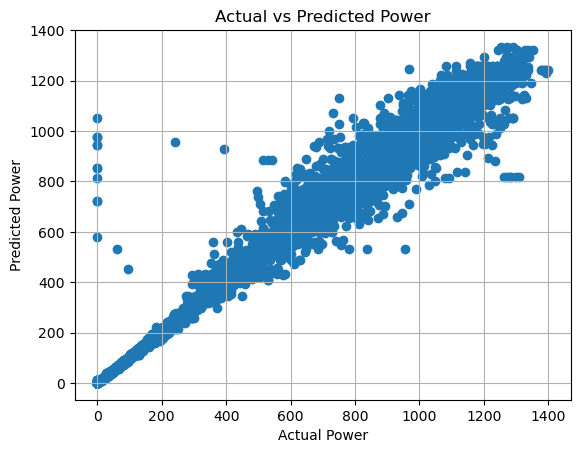


Mean Squared Error: 3885.339611497222


In [26]:
# ================================
# FINAL PREDICTION + MAINTENANCE + GRAPH
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prediction
predicted = model.predict(X_test)

# Convert to numpy (safe)
y_actual = np.array(y_test)

# Maintenance Logic (safe division)
threshold = 0.2
status = []

for actual, pred in zip(y_actual, predicted):
    if actual == 0:
        status.append("⚠️ Low Output")
    elif abs(actual - pred) / actual > threshold:
        status.append("⚠️ Maintenance Required")
    else:
        status.append("✅ Working Fine")

# Create Result Table
results = pd.DataFrame({
    "Actual Power": y_actual,
    "Predicted Power": predicted,
    "Status": status
})

# Show top results
print("===== SAMPLE OUTPUT =====")
print(results.head(10))

# ================================
# GRAPH VISUALIZATION
# ================================

plt.figure()
plt.scatter(y_actual, predicted)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power")
plt.grid()
plt.show()

# ================================
# BASIC ACCURACY CHECK
# ================================

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_actual, predicted)
print("\nMean Squared Error:", mse)

===== SAMPLE OUTPUT =====
       Actual   Predicted        Status
0  915.828571  920.709054  Working Fine
1    0.000000    0.000000    Low Output
2  420.516667  490.258292  Working Fine
3  180.862500  177.002201  Working Fine
4  464.700000  475.759625  Working Fine
5    0.000000    0.000000    Low Output
6  593.962500  605.946469  Working Fine
7    0.000000    0.000000    Low Output
8  179.785714  174.947586  Working Fine
9  586.814286  600.776712  Working Fine


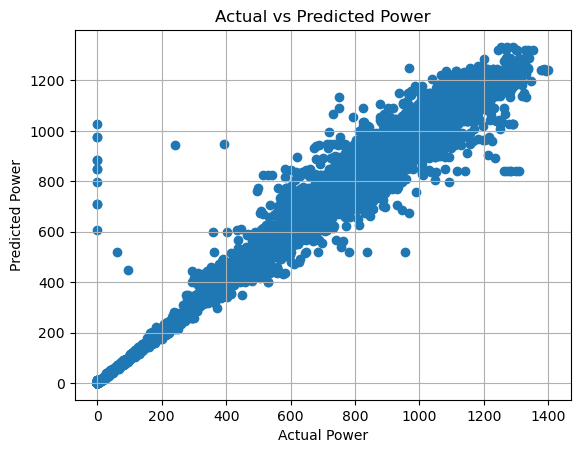

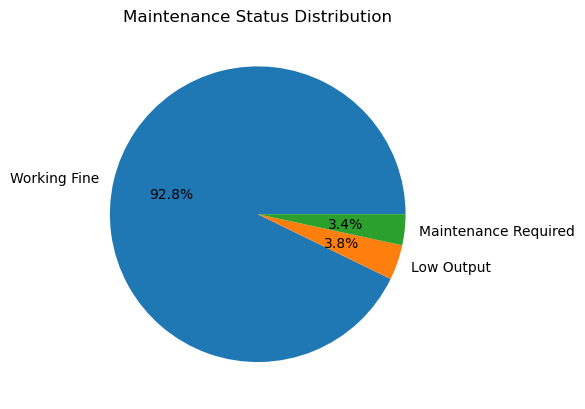


Mean Squared Error: 3913.7182980648768
R2 Score (Accuracy): 0.9727329854445392


In [27]:
# ==========================================
# FINAL ADVANCED SOLAR MAINTENANCE SYSTEM
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ======================
# TRAIN BETTER MODEL
# ======================

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# PREDICTION
# ======================

predicted = model.predict(X_test)
y_actual = np.array(y_test)

# ======================
# MAINTENANCE LOGIC
# ======================

threshold = 0.2
status = []

for actual, pred in zip(y_actual, predicted):
    if actual == 0:
        status.append("Low Output")
    elif abs(actual - pred) / actual > threshold:
        status.append("Maintenance Required")
    else:
        status.append("Working Fine")

# ======================
# RESULT TABLE
# ======================

results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": predicted,
    "Status": status
})

print("===== SAMPLE OUTPUT =====")
print(results.head(10))

# ======================
# GRAPH 1: ACTUAL vs PREDICTED
# ======================

plt.figure()
plt.scatter(y_actual, predicted)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power")
plt.grid()
plt.show()

# ======================
# GRAPH 2: PIE CHART (🔥)
# ======================

status_counts = results["Status"].value_counts()

plt.figure()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title("Maintenance Status Distribution")
plt.show()

# ======================
# ACCURACY CHECK
# ======================

mse = mean_squared_error(y_actual, predicted)
r2 = r2_score(y_actual, predicted)

print("\nMean Squared Error:", mse)
print("R2 Score (Accuracy):", r2)

In [28]:
print(results.sample(10))

           Actual    Predicted        Status
5134   946.137500   993.045742  Working Fine
7193   350.300000   348.410395  Working Fine
2681    81.525000    81.069382  Working Fine
4598  1051.614286  1148.862166  Working Fine
2084   870.428571   866.108453  Working Fine
6330   667.342857   622.193706  Working Fine
5055   923.500000   829.019130  Working Fine
5667  1067.375000  1223.166334  Working Fine
4361    63.900000    63.581213  Working Fine
182    193.128571   191.066988  Working Fine
